In [9]:
from sage.all import *
from sage.all import *
import pickle
import time


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)[0]
       
        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return (results)

start=time.time()

N=5
k=6

   
        
precision=2800 # need a long list to find 350 primes
gos=galois_orbit_sum(N, k, precision)
gos=gos[0]
print(gos[:20])

print()
indexed_list=[(n,gos[n]) for n in range(1,2800)]
print(indexed_list[:20])
print()
prime_list=[pair[1] for pair in indexed_list if is_prime(pair[0])]
print(prime_list[:20])

[0, 1, 2, -4, -28, 25, -8, 192, -120, -227, 50, -148, 112, 286, 384, -100, 656, -1678, -454, 1060]

[(1, 1), (2, 2), (3, -4), (4, -28), (5, 25), (6, -8), (7, 192), (8, -120), (9, -227), (10, 50), (11, -148), (12, 112), (13, 286), (14, 384), (15, -100), (16, 656), (17, -1678), (18, -454), (19, 1060), (20, -700)]

[2, -4, 25, 192, -148, 286, -1678, 1060, 2976, -3410, -2448, 182, -9398, -1244, -12088, 23846, -20020, 32302, 60972, -32648]


('j_list', 20)
('j_list', 40)
('j_list', 60)
('j_list', 80)
('j_list', 100)
('j_list', 120)
('j_list', 140)
('j_list', 160)
('j_list', 180)
('j_list', 200)
('j_list', 220)
('j_list', 240)
('j_list', 260)
('j_list', 280)
('j_list', 300)
('j_list', 320)
('j_list', 340)
('j_list', 360)
('j_list', 380)
('j_list', 400)
(1, 0.0021675984064737958)
(2, 0.0025902509689331053)
(3, 0.0028467496236165364)
(4, 0.0028606692949930826)
(5, 0.0028819998105367025)
(6, 0.0028977036476135255)
(7, 0.0029526988665262857)
(8, 0.003006120522816976)
(9, 0.0030579487482706707)
(10, 0.0031135042508443197)
(11, 0.0032261013984680176)
(12, 0.0033507347106933594)
(13, 0.003460999329884847)
(14, 0.0036034981409708657)
(15, 0.0037615180015563967)
(16, 0.004015449682871501)
(17, 0.004311800003051758)
(18, 0.004493200778961181)
(19, 0.0047771175702412925)
(20, 0.005121171474456787)
(21, 0.005431850751241048)
(22, 0.0057509501775105795)
(23, 0.006163366635640462)
(24, 0.006742151578267416)
(25, 0.007186631361643474)
(26

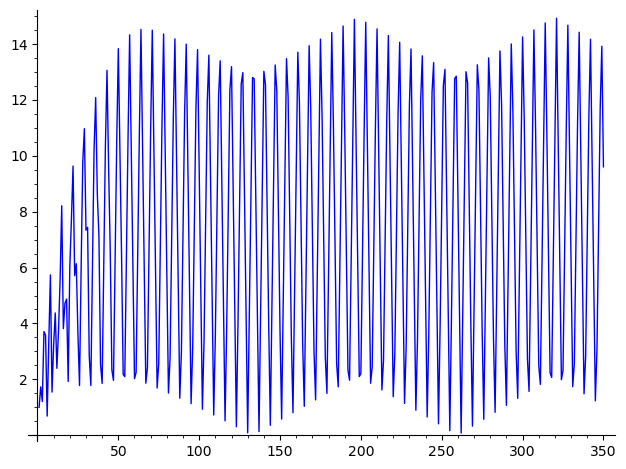

In [10]:
from sage.all import *
from sage.all import *
import pickle
import time


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)[0]
       
        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return (results)

start=time.time()

N=5
k=6

   
        
precision=2800 # need a long list to find 350 primes
gos=galois_orbit_sum(N, k, precision)
gos=gos[0]



indexed_list=[(n,gos[n]) for n in range(1,2800)]

prime_list=[pair[1] for pair in indexed_list if is_prime(pair[0])]


h_list=[1]+prime_list
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in range(1,n):
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    j_list.append((n,j_n))
    if n%20==0:
        print(("j_list",n))
    





with open('/Users/barrybrent/data2/run10apr26no31.txt', 'wb') as wfile:
    pickle.dump(gos[0], wfile) #<<<<<< gos[0] bc len gos >=0
    
with open('/Users/barrybrent/data2/run10apr26no32.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable


charpol_list=[]
roots_list=[]

mins_list=[]


for n in range(1, 351):
    now=time.time()
    elapsed=(now-start)/60
    print((n,elapsed))
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run10apr26no33.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run10apr26no34.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run10apr26no35.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped